PyTorch에서는 torch.nn.RNN, torch.nn.LSTM, torch.nn.GRU 클래스를 사용하여 순환 신경망을 쉽게 구현할 수 있습니다.

각 클래스는 공통적으로 아래와 같은 주요 파라미터를 가집니다.

- input_size: 입력 특성의 차원 (예: 피처 개수)

- hidden_size: 은닉 상태의 차원 (뉴런 개수)

- num_layers: RNN의 레이어 개수 (층이 깊을수록 복잡한 패턴 학습 가능)

- batch_first: True이면 입력 텐서의 첫 번째 차원이 배치 크기가 됨 (기본값은 False)

- dropout: 층 간 드롭아웃 적용 여부 (과적합 방지)

- bidirectional: 양방향 RNN 사용 여부 (기본값 False)


In [1]:
# ====================================================================================================
# [이번 학습의 목표: '기억'을 가진 신경망, RNN의 작동 원리 완벽 이해하기]
#
# [개념적 개요 및 왜 이 작업을 하는가?]
# 이 코드의 목표는 순차적인(Sequential) 데이터, 예를 들어 문장, 시계열 데이터 등을 처리하기 위해
# 특별히 설계된 '순환 신경망(Recurrent Neural Network, RNN)'의 가장 기본적인 작동 원리를 이해하는 것입니다.
# DNN이나 CNN과 달리, RNN은 '기억'을 할 수 있습니다. "나는 학교에 간다" 라는 문장을 이해하기 위해
# "나는"을 읽고, 그 기억을 바탕으로 "학교에"를 읽고, 또 그 기억을 바탕으로 "간다"를 읽는
# 인간의 독서 방식과 매우 유사합니다. 이 '기억'의 역할을 하는 것이 바로 '은닉 상태(Hidden State)'입니다.
#
# [핵심 비유: 문장을 읽고 이해하는 AI 독서가]
#
# 1. `nn.RNN` (모델): 문장을 읽고, 각 단어의 의미와 문맥을 파악하여 머릿속에 '요약'하는 'AI 독서가'.
#
# 2. `input_size`: 독서가가 읽을 '단어' 하나의 표현 방식. (예: 각 단어는 10개의 숫자로 된 코드)
#
# 3. `hidden_size`: 독서가의 '단기 기억 용량'. (예: 문맥을 20개의 숫자로 요약하여 기억함)
#
# 4. 입력 텐서 `x`: 독서가에게 주어진 '읽을 책'. (예: 3개의 단어로 이루어진 문장 32개)
#
# 5. 출력 `out`: 독서가가 책을 읽으며 **"매 단어를 읽을 때마다 머릿속에 떠올랐던 모든 생각들"**을 기록한 상세한 '독서록'.
#
# 6. 출력 `hidden`: 독서가가 책의 **"마지막 단어까지 다 읽고 난 후의 최종 결론"**만을 요약한 '한 줄 요약'.
#
# [지금 무엇을 하고 있는가?]
# 우리는 지금부터 이 'AI 독서가'가 어떻게 한 단어씩 책을 읽어 나가며,
# 머릿속의 기억('은닉 상태')을 계속 업데이트하는지, 그리고 그 결과물인 '독서록(`out`)'과
# '한 줄 요약(`hidden`)'이 각각 무엇을 의미하는지를 배우고 있습니다.
# ====================================================================================================


# --- 1. 기본 도구 준비: 라이브러리 불러오기 ---
import torch
import torch.nn as nn


# --- 2. AI 독서가(RNN) 생성 및 능력치 설정 ---
# [흐름] `nn.RNN` 클래스를 사용하여, 특정 규칙에 따라 작동하는 RNN 기계를 하나 만듭니다.

rnn = nn.RNN(
    # [입력 데이터 스펙] "이 독서가는 10개의 숫자로 암호화된 단어만 읽을 수 있습니다."
    # `input_size=10`: RNN에 한 번에 들어올 데이터 조각(예: 단어 하나)의 '특성 개수'입니다.
    #                  "나는" 이라는 단어를 컴퓨터가 이해하도록 10차원 벡터로 표현했다는 의미입니다.
    input_size = 10,

    # [기억 용량 스펙] "이 독서가의 단기 기억 용량은 20입니다."
    # `hidden_size=20`: RNN의 '기억(은닉 상태, Hidden State)'을 몇 개의 숫자로 표현할지를 의미합니다.
    #                   이 숫자가 클수록 더 복잡한 문맥을 기억할 수 있습니다.
    hidden_size = 20,

    # [깊이 스펙] "이 독서가는 혼자 일합니다." (여러 명의 독서가가 계층적으로 일할 수도 있음)
    # `num_layers=1`: RNN 층을 몇 개나 쌓을지를 결정합니다.
    num_layers = 1,

    # [입력 형식 약속] "책(데이터)은 (단어 순서, 책 권수, 단어 암호) 순으로 제본되어야 합니다."
    # `batch_first=False`: 입력 텐서의 차원 순서를 `(시퀀스_길이, 배치_크기, 입력_크기)`로 하겠다는 약속입니다.
    #                      이것이 PyTorch RNN의 기본값(default)입니다.
    batch_first = False
)


# --- 3. 읽을 책(입력 데이터) 준비 ---
# [흐름] "나는 학교에 간다"와 같은 문장 32개를 동시에 처리하는 상황을 가정합니다.

# [구동 과정 심층 분석] `x = torch.randn(3, 32, 10)`
# 위에서 `batch_first=False`로 약속했으므로, `(시퀀스_길이, 배치_크기, 입력_크기)` 순서에 맞춰 텐서를 생성합니다.
# - `3` (시퀀스 길이): 문장이 "나는", "학교에", "간다" **3개의 단어(타임스텝)**로 구성됨.
# - `32` (배치 크기): 서로 다른 **32개의 문장**을 한 묶음으로 동시에 처리함.
# - `10` (입력 크기): 각 단어가 **10차원의 벡터**로 표현됨.
x = torch.randn(3, 32, 10)


# --- 4. 독서 시작 (순전파) 및 결과 확인 ---
# [구동 과정] `out, hidden = rnn(x)`:
#            생성된 AI 독서가(`rnn`)에게 읽을 책 묶음(`x`)을 전달하여 독서를 시작합니다.
#            독서가(`rnn`)는 책을 모두 읽고, 두 개의 결과물, 즉 '독서록(`out`)'과 '한 줄 요약(`hidden`)'을 반환합니다.
out, hidden = rnn(x)

# [구동 과정] 각 결과물의 모양(shape)을 출력합니다.
print(f"독서록(out)의 모양: {out.shape}")
print(f"한 줄 요약(hidden)의 모양: {hidden.shape}")
# [결과] torch.Size([3, 32, 20]) torch.Size([1, 32, 20])


# --- 5. [핵심] '독서록(out)'과 '한 줄 요약(hidden)' 심층 분석 ---
# [흐름] AI 독서가가 한 문장("나는 학교에 간다")을 읽을 때, 그 머릿속에서 일어나는 일을 시간 순서대로 따라가 봅니다.

# [t=0] 독서 시작 전:
#       독서가의 머릿속(초기 은닉 상태)은 아무 생각이 없는 '백지 상태'입니다. (보통 0으로 채워진 20차원 벡터)

# [t=1] 첫 번째 단어 "나는"을 읽는 순간:
#       - 입력: "나는"(10차원 벡터) + 백지 상태(20차원 벡터)
#       - 처리: 독서가가 두 정보를 종합하여, "나는..." 이라는 문맥을 담은 **첫 번째 생각(은닉 상태_1)**을 머릿속에 떠올립니다. (20차원 벡터)
#       - 기록: 이 '첫 번째 생각'을 **독서록(`out`)의 1페이지**에 기록합니다.

# [t=2] 두 번째 단어 "학교에"를 읽는 순간:
#       - 입력: "학교에"(10차원 벡터) + **바로 이전의 생각(은닉 상태_1)**
#       - 처리: 독서가가 두 정보를 종합하여, "나는 학교에..." 라는 더 구체적인 문맥을 담은 **두 번째 생각(은닉 상태_2)**을 떠올립니다.
#       - 기록: 이 '두 번째 생각'을 **독서록(`out`)의 2페이지**에 기록합니다.

# [t=3] 세 번째 단어 "간다"를 읽는 순간:
#       - 입력: "간다"(10차원 벡터) + **바로 이전의 생각(은닉 상태_2)**
#       - 처리: 독서가가 두 정보를 종합하여, "나는 학교에 간다" 라는 완성된 문장의 의미를 담은 **세 번째 생각(은닉 상태_3)**을 떠올립니다.
#       - 기록: 이 '세 번째 생각'을 **독서록(`out`)의 3페이지**에 기록합니다.


# --- [결과물 분석] ---

# ### `out` 텐서: '과정'의 모든 기록 (상세한 독서록)
# - **모양:** `(시퀀스_길이, 배치_크기, 은닉_상태_크기)` -> `(3, 32, 20)`
# - **의미:** AI 독서가가 각 단어를 읽을 때마다 머릿속에 떠올랐던 **'모든 생각들'**을 시간 순서대로 모아놓은 것입니다.
# - **`out[0]`**: "나는"까지 읽었을 때의 생각들 (32개 문장 각각에 대한)
# - **`out[1]`**: "나는 학교에"까지 읽었을 때의 생각들
# - **`out[2]`**: "나는 학교에 간다"까지 읽었을 때의 생각들 (가장 마지막 생각)
# - **용도:** 각 단어의 품사를 예측하는 등, 문장 내의 모든 위치에 대한 정보가 필요할 때 사용됩니다.

# ### `hidden` 텐서: '최종' 결과물 (핵심 한 줄 요약)
# - **모양:** `(층_개수, 배치_크기, 은닉_상태_크기)` -> `(1, 32, 20)`
# - **의미:** 오직 **'마지막 단어'까지 모두 읽고 난 후의 최종 생각**만을 담고 있습니다.
#           전체 문장의 의미를 하나의 벡터로 압축한 '문맥 벡터(Context Vector)'라고 할 수 있습니다.
# - **[중요] `out`의 마지막 페이지와 `hidden`은 사실상 같은 정보를 담고 있습니다.**
#   - `out`의 마지막 페이지 (`out[-1]`)의 모양은 `(32, 20)` 입니다.
#   - `hidden`의 모양은 `(1, 32, 20)` 으로, 불필요한 껍데기(차원)가 하나 더 있을 뿐입니다.
#   - `hidden.squeeze(0)`를 하면 `out[-1]`과 완전히 동일한 텐서가 됩니다.
# - **용도:** 문장 전체를 긍정/부정으로 분류하거나, 이 문장을 다른 언어로 번역하는 등, 전체 문장을 요약한 정보가 필요할 때 주로 사용됩니다.

독서록(out)의 모양: torch.Size([3, 32, 20])
한 줄 요약(hidden)의 모양: torch.Size([1, 32, 20])


In [2]:
# ====================================================================================================
# [목표]
# 이 코드는 `batch_first=True` 옵션을 사용하여, 많은 딥러닝 프레임워크와 논문에서 더 흔하게 사용되는
# `(배치_크기, 시퀀스_길이, 입력_크기)` 형태의 데이터 형식을 다루는 방법을 이해하는 것입니다.
# 기능적으로는 이전과 동일하지만, 텐서의 차원 순서만 바뀝니다.
# ====================================================================================================
import torch
import torch.nn as nn

# [RNN 생성]
# 유일한 변경점은 `batch_first = True` 입니다.
rnn = nn.RNN(input_size = 10, hidden_size = 20, num_layers = 1, batch_first = True)

# [입력 텐서 생성]
# `batch_first=True` 약속에 따라, `(배치_크기, 시퀀스_길이, 입력_크기)` 순서로 텐서를 생성합니다.
# 데이터의 의미는 이전과 동일하지만, 메모리상에 저장되는 순서만 변경된 것입니다.
x = torch.randn(32, 3, 10)

# [순전파 및 출력 확인]
out, hidden = rnn(x)
print(out.shape, hidden.shape)
# [출력 결과 분석: torch.Size([32, 3, 20]) torch.Size([1, 32, 20])]

# [`out` 텐서의 변화]
#   - 모양: `(배치_크기, 시퀀스_길이, 은닉_상태_크기)` -> `(32, 3, 20)`
#   - 의미: `batch_first=True` 설정에 따라, 출력 `out`의 첫 번째 차원도 '배치 크기'가 됩니다.
#           내용적으로는 이전과 동일하게 모든 타임스텝의 은닉 상태를 담고 있습니다.

# [`hidden` 텐서의 불변성]
#   - 모양: `(층_개수 * 방향_개수, 배치_크기, 은닉_상태_크기)` -> `(1, 32, 20)`
#   - [매우 중요!] `hidden` 텐서의 모양은 `batch_first` 옵션에 영향을 받지 않고 '항상 동일'합니다.
#     이는 `hidden`이 시퀀스의 시간적 흐름보다는, 최종적인 '상태' 자체에 초점을 맞추기 때문입니다.

torch.Size([32, 3, 20]) torch.Size([1, 32, 20])


In [3]:
# --- 2. [핵심] `batch_first=True`일 때 슬라이싱 심층 분석 ---
# [흐름] '문장별로 정리된' 새로운 캐비닛(`out` 모양: `(32, 3, 20)`)에서 정보를 꺼내는 방법을 알아봅니다.
#        사용자께서 보여주신 코드와 그에 대한 올바른 해석, 그리고 의도에 맞는 수정 제안을 포함합니다.

# --- [코드 1] `out[-1, :, :]` ---
# [해석] "문장별로 정리된 캐비닛(`out`)에서, 맨 마지막 서랍 하나만 통째로 꺼내줘."
# [구동 과정 심층 분석]: `out` 텐서 `(32, 3, 20)`에 적용됩니다.
# - `-1` (첫 번째 차원, 배치): 32개의 서랍(문장) 중 **마지막 서랍(32번 문장)**을 선택합니다.
# - `:` (두 번째 차원, 시퀀스): 그 서랍 안에 있는 **모든 파일(3개의 단어)**을 선택합니다.
# - `:` (세 번째 차원, 특징): 각 파일의 **모든 내용(20개 특징)**을 가져옵니다.
# [결과] **"32번 문장 하나"**의 **"모든 시간(1~3번 단어)에 대한 생각의 기록"**입니다.
# [최종 모양] `(3, 20)`
print("\n--- `out[-1, :, :]` 분석 ---")
print("의미: 32개의 문장 중 '마지막 문장'의 전체 독서 기록")
print(f"결과 모양: {out[-1, :, :].shape}")

tensor([[-0.3925, -0.5555, -0.2097,  0.2938,  0.6490, -0.1492,  0.1244, -0.4710,
          0.2066,  0.2940,  0.2374, -0.3589, -0.0911,  0.0117, -0.4315, -0.0617,
         -0.3266, -0.1914, -0.4635,  0.0881],
        [ 0.4023,  0.2885, -0.3606,  0.6134, -0.2791,  0.2396, -0.1548,  0.1775,
          0.7771,  0.4413, -0.1557,  0.7485,  0.6551,  0.1203,  0.7693, -0.2789,
         -0.1969,  0.3724,  0.1568, -0.6291],
        [-0.4065, -0.0017, -0.5064,  0.6691, -0.4311, -0.2881,  0.5201,  0.7135,
          0.0561, -0.5844,  0.1991,  0.3020,  0.7272, -0.0613,  0.8013, -0.1569,
         -0.3643,  0.6328, -0.1744,  0.8257]], grad_fn=<SliceBackward0>)

In [4]:
# --- [코드 2] `hidden[:, -1, :]` ---
# [해석] "`hidden`이라는 최종 요약 보고서 묶음에서, 맨 마지막 학생의 요약본만 꺼내줘."
# [구동 과정 심층 분석]: `hidden` 텐서 `(1, 32, 20)`에 적용됩니다.
# - `:` (첫 번째 차원, 층수): 1개의 층 전체를 선택합니다.
# - `-1` (두 번째 차원, 배치): 32개의 요약본(문장) 중 **마지막 요약본(32번 문장)** 하나만 선택합니다.
# - `:` (세 번째 차원, 특징): 그 요약본의 **모든 내용(20개 특징)**을 가져옵니다.
# [결과] **"32번 문장 하나"**의 **"최종 요약본"**입니다.
# [최종 모양] `(1, 20)`
print("\n--- `hidden[:, -1, :]` 분석 ---")
print("의미: 32개의 문장 중 '마지막 문장'의 최종 요약본")
print(f"결과 모양: {hidden[:, -1, :].shape}")

tensor([[-0.4065, -0.0017, -0.5064,  0.6691, -0.4311, -0.2881,  0.5201,  0.7135,
          0.0561, -0.5844,  0.1991,  0.3020,  0.7272, -0.0613,  0.8013, -0.1569,
         -0.3643,  0.6328, -0.1744,  0.8257]], grad_fn=<SliceBackward0>)

In [18]:
# --- 3. 우리의 진짜 목표: "모든 문장의 마지막 정보" 추출하는 올바른 방법 ---
# [개념] 대부분의 경우, 우리가 진짜 원하는 것은 "모든 32개 문장 각각의, 마지막 순간의 생각"입니다.
#        `batch_first=True`일 때는 다음과 같이 접근해야 합니다.

print("\n--- [올바른 접근법] 모든 문장의 '최종' 정보 추출 ---")
# [방법 1] `out` 텐서 사용하기: `out[:, -1, :]`
# [해석] "모든 서랍(모든 문장, `:`)을 다 열어보고, 각 서랍에서 맨 마지막 파일(마지막 단어, `-1`)만 꺼내줘."
# [구동 과정]: `out` 텐서 `(32, 3, 20)`에 적용됩니다.
# - `:` (첫 번째 차원, 배치): 32개의 문장 **전부**를 선택합니다.
# - `-1` (두 번째 차원, 시퀀스): 각 문장의 3개 단어 중 **마지막 단어** 시점의 정보만 선택합니다.
# - `:` (세 번째 차원, 특징): 그 정보의 **모든 내용(20개 특징)**을 가져옵니다.
# [결과] **"모든 32개 문장"** 각각의 **"최종 생각"**입니다.
# [최종 모양] `(32, 20)`
correct_slice_from_out = out[:, -1, :]
print(f"out[:, -1, :]의 결과 모양: {correct_slice_from_out.shape}")


--- [올바른 접근법] 모든 문장의 '최종' 정보 추출 ---
out[:, -1, :]의 결과 모양: torch.Size([32, 20])


In [19]:
# [방법 2] `hidden` 텐서 사용하기 (가장 간편하고 일반적인 방법)
# [해석] "`hidden` 요약 보고서에서, 불필요한 겉표지(첫 번째 차원)만 제거한다."
# [구동 과정]: `hidden` 텐서 `(1, 32, 20)`에 적용됩니다.
# - `squeeze(0)`: 크기가 1인 0번 차원을 제거하여 모양을 `(32, 20)`으로 만듭니다.
#   `hidden`은 `batch_first` 설정과 무관하게 모양이 동일하므로, 이 방법은 언제나 통용됩니다.
correct_slice_from_hidden = hidden.squeeze(0)
print(f"hidden.squeeze(0)의 결과 모양: {correct_slice_from_hidden.shape}")

# [검증] 두 방법으로 추출한 결과가 완전히 동일한지 확인합니다.
print(f"두 방법의 결과가 동일한가? {torch.allclose(correct_slice_from_out, correct_slice_from_hidden)}")

hidden.squeeze(0)의 결과 모양: torch.Size([32, 20])
두 방법의 결과가 동일한가? True


# LSTM

In [5]:
# =-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-
# [전체적인 목표 및 개념적 개요]
# 이 코드의 목표는 기본적인 RNN의 한계점을 극복하기 위해 등장한 'LSTM(Long Short-Term Memory)'의
# 작동 원리를 이해하는 것입니다.
#
# [기존 RNN의 문제점: 장기 기억 상실 (Vanishing Gradient Problem)]
# - 기본 RNN은 문장이 길어질수록, 문장 맨 앞에 나왔던 중요한 정보를 뒤까지 전달하지 못하고
#   '잊어버리는' 경향이 있습니다. 이를 '장기 의존성 문제'라고 합니다.
#
# [LSTM의 해결책: 두 종류의 기억 - '단기 기억'과 '장기 기억']
# LSTM은 이 문제를 해결하기 위해 두 개의 메모리 라인을 사용합니다:
# 1. 은닉 상태 (Hidden State, h_t): RNN과 동일한 '단기 기억'입니다. 현재 타임스텝의 출력을 결정하는 데
#    직접적으로 사용되며, 비교적 단기적인 문맥을 담습니다.
# 2. 셀 상태 (Cell State, c_t): [LSTM의 핵심!] LSTM에만 존재하는 '장기 기억'입니다.
#    마치 컨베이어 벨트처럼, 문장의 처음부터 끝까지 중요한 정보를 쭉 전달하는 역할을 합니다.
#    이 장기 기억은 중간에 복잡한 연산을 거의 거치지 않아 정보가 소실될 가능성이 적습니다.
#
# [기억을 관리하는 3개의 문(Gate)]
# LSTM은 '게이트(Gate)'라는 메커니즘을 통해 이 두 기억을 정교하게 제어합니다.
# (첨부된 다이어그램 참고)
#   a. 망각 게이트 (Forget Gate): 과거의 장기 기억(c_{t-1})에서 '어떤 정보를 잊어버릴지' 결정합니다.
#   b. 입력 게이트 (Input Gate): 현재 정보(x_t)와 단기 기억(h_{t-1}) 중에서 '어떤 새로운 정보를 장기 기억에 추가할지' 결정합니다.
#   c. 출력 게이트 (Output Gate): 업데이트된 장기 기억(c_t)을 바탕으로, '어떤 정보를 현재의 단기 기억(h_t)으로 내보낼지' 결정합니다.
#
# 이 코드는 PyTorch의 `nn.LSTM`을 사용하여 이 복잡한 구조를 단 한 줄로 구현하고,
# 그 결과로 나오는 세 개의 출력(`out`, `hidden`, `cell`)의 의미를 심층적으로 분석합니다.
# =-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-

import torch
import torch.nn as nn

# --- 1. LSTM 레이어 생성 ---
# nn.LSTM 클래스를 사용하여 LSTM 기계를 만듭니다. 파라미터는 nn.RNN과 거의 동일합니다.
lstm = nn.LSTM(input_size = 10, hidden_size = 20, num_layers = 1, batch_first = True)

# --- 2. 가상의 입력 데이터 생성 ---
# `batch_first=True`이므로, `(배치_크기, 시퀀스_길이, 입력_크기)` 순서로 텐서를 생성합니다.
x = torch.randn(32, 3, 10)

# --- 3. LSTM 순전파 실행 및 출력 확인 ---
# [순전파]
# LSTM은 RNN과 달리, 마지막 상태를 나타내는 부분이 `(hidden, cell)` 형태의 튜플(tuple)로 반환됩니다.
out, (hidden, cell) = lstm(x)

# [출력 형태 확인]
print(out.shape, hidden.shape, cell.shape)
# [출력 결과 분석: torch.Size([32, 3, 20]) torch.Size([1, 32, 20]) torch.Size([1, 32, 20])]
# - `out`과 `hidden`의 모양은 RNN과 동일하지만, `cell`이라는 새로운 출력이 추가되었습니다.

torch.Size([32, 3, 20]) torch.Size([1, 32, 20]) torch.Size([1, 32, 20])


In [6]:
# --- 4. 출력 텐서 `out`, `hidden`, `cell`의 의미 심층 분석 ---

# [`out` 텐서: 모든 타임스텝의 '단기 기억' 모음]
#   - 모양: `(배치_크기, 시퀀스_길이, 은닉_상태_크기)` -> `(32, 3, 20)`
#   - 의미: RNN의 `out`과 완벽하게 동일합니다. 각 타임스텝(단어)을 처리한 직후의 '단기 기억(은닉 상태, h_t)'들을
#           시간 순서대로 모두 모아놓은 것입니다.
#   - `out[:, 0, :]`: "나는"까지 처리했을 때의 단기 기억(h_0)
#   - `out[:, 1, :]`: "나는 학교에"까지 처리했을 때의 단기 기억(h_1)
#   - `out[:, 2, :]`: "나는 학교에 간다"까지 처리했을 때의 단기 기억(h_2)

# [`hidden` 텐서: '최종 단기 기억']
#   - 모양: `(층_개수 * 방향_개수, 배치_크기, 은닉_상태_크기)` -> `(1, 32, 20)`
#   - 의미: RNN의 `hidden`과 완벽하게 동일합니다. 오직 '마지막 타임스텝'의 단기 기억(h_2)만을 담고 있습니다.
#   - [중요] `out`의 마지막 조각과 `hidden`은 여전히 같은 정보를 담고 있습니다.
#     - `out[:, -1, :]` (모양: `(32, 20)`)과 `hidden.squeeze(0)` (모양: `(32, 20)`)은 동일한 텐서입니다.

# [`cell` 텐서: '최종 장기 기억']
#   - 모양: `(층_개수 * 방향_개수, 배치_크기, 은닉_상태_크기)` -> `(1, 32, 20)`
#   - 의미: [LSTM의 핵심] 오직 '마지막 타임스텝'의 장기 기억(셀 상태, c_2)만을 담고 있습니다.
#           이것은 문장 전체를 관통하며 누적된 핵심 정보의 정수(essence)입니다. `out`에는 이 정보가 직접적으로
#           노출되지 않습니다.
#   - 용도: 이 `cell` 상태는 다음 문장을 처리하거나, 더 깊은 LSTM 레이어로 정보를 전달할 때 `hidden` 상태와
#           함께 초기 상태로 사용되어, 장기적인 문맥을 계속해서 이어나갈 수 있게 해줍니다.

# --- (참고) 사용자 코드 라인 분석 ---

out[-1, :, :]
# [설명] `out`의 모양이 `(32, 3, 20)`이므로, `out[-1, :, :]`는 "32개 문장 중 마지막 문장"의 모든
#        타임스텝에 대한 단기 기억(`(3, 20)` 모양)을 선택하는 코드입니다.

tensor([[-0.1362, -0.0868, -0.0195,  0.1062,  0.0915,  0.0716, -0.0604,  0.0762,
         -0.0985, -0.0610, -0.0238,  0.0356,  0.1362, -0.0532,  0.0389,  0.0113,
         -0.0327, -0.2001,  0.1589,  0.0017],
        [-0.2231, -0.3150, -0.1858,  0.0577,  0.1270,  0.2267, -0.0975,  0.0654,
         -0.1492, -0.0801, -0.1521, -0.0004,  0.2034,  0.1296, -0.0429,  0.0175,
         -0.0154, -0.1364,  0.2224,  0.0128],
        [ 0.0613, -0.1512, -0.0252, -0.0882,  0.0615,  0.1176,  0.0025,  0.0860,
          0.1406, -0.0712, -0.2374, -0.0583, -0.1216,  0.0964, -0.0509, -0.0200,
          0.1981,  0.0194,  0.1195, -0.0466]], grad_fn=<SliceBackward0>)

In [7]:
hidden[:, -1, :]
# [설명] `hidden`의 모양이 `(1, 32, 20)`이므로, `hidden[:, -1, :]`는 "32개 문장 중 마지막 문장"의
#        '최종 단기 기억'(`(1, 20)` 모양)을 선택하는 코드입니다.

tensor([[ 0.0613, -0.1512, -0.0252, -0.0882,  0.0615,  0.1176,  0.0025,  0.0860,
          0.1406, -0.0712, -0.2374, -0.0583, -0.1216,  0.0964, -0.0509, -0.0200,
          0.1981,  0.0194,  0.1195, -0.0466]], grad_fn=<SliceBackward0>)

In [8]:
cell[:, -1, :]
# [설명] `cell`의 모양이 `(1, 32, 20)`이므로, `cell[:, -1, :]`는 "32개 문장 중 마지막 문장"의
#        '최종 장기 기억'(`(1, 20)` 모양)을 선택하는 코드입니다.

# 얘는 좀 다르게 나온다
# [주석에 대한 부연 설명]
# `hidden`과 `cell`은 구조적으로는 동일한 모양을 가지지만, 담고 있는 '정보의 종류'와 '역할'이 다릅니다.
# - `hidden` (h_t): 필터링된 정보. 현재 타임스텝의 출력을 위해 외부에 '보여주는' 기억입니다.
# - `cell` (c_t): 핵심 정보의 고속도로. 다음 타임스텝으로 정보를 온전히 전달하는 데 초점을 맞춘 '내부적인' 기억입니다.
# 따라서 이 둘의 텐서 값은 당연히 다르게 나옵니다. 이것이 바로 LSTM이 RNN보다 더 정교한 기억 메커니즘을
# 가지고 있다는 증거입니다.

tensor([[ 0.1069, -0.3587, -0.0511, -0.2770,  0.0771,  0.2263,  0.0043,  0.1932,
          0.2799, -0.2476, -0.3618, -0.0958, -0.1848,  0.1628, -0.0634, -0.0325,
          0.3677,  0.0541,  0.3031, -0.0849]], grad_fn=<SliceBackward0>)

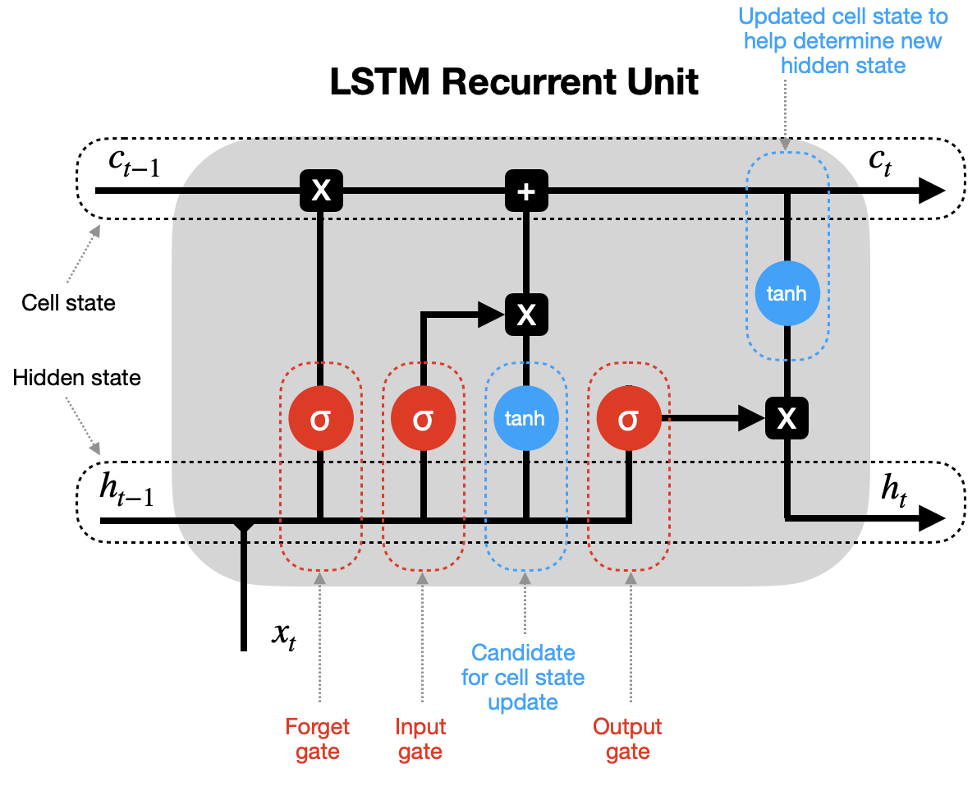

# GRU

In [9]:
# =-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-
# [전체적인 목표 및 개념적 개요]
# 이 코드의 목표는 LSTM의 강력한 장기 기억 능력을 유지하면서도, 구조를 더 단순화하고 계산 효율성을 높인
# 'GRU(Gated Recurrent Unit)'의 작동 원리를 이해하는 것입니다.
#
# [LSTM에서 무엇이 바뀌었는가? - '효율적인 기억 관리']
# - LSTM의 복잡성: '단기 기억(Hidden State)'과 '장기 기억(Cell State)'이라는 두 개의 메모리 라인을
#                  유지하고, 이를 3개의 게이트(Forget, Input, Output)로 제어하는 것은 다소 복잡하고 계산량이 많습니다.
# - GRU의 단순화: GRU는 이 문제를 두 가지 혁신적인 방법으로 해결합니다.
#   1. 기억의 통합: '단기 기억'과 '장기 기억'을 하나의 '은닉 상태(Hidden State)'로 통합합니다.
#      즉, 별도의 Cell State 컨베이어 벨트가 없습니다.
#   2. 게이트의 축소: 3개의 게이트를 2개의 게이트로 줄였습니다.
#      a. 업데이트 게이트 (Update Gate): LSTM의 망각(Forget) 게이트와 입력(Input) 게이트의 역할을 합친 것과 같습니다.
#         과거 정보와 현재 정보 중 '어느 것을 얼마나 반영할지' 그 비율을 결정합니다.
#      b. 리셋 게이트 (Reset Gate): 과거 정보(이전 은닉 상태) 중에서 현재 정보를 만드는 데 '얼마나 무시할지' 결정합니다.
#
# [결론: 더 가볍고 빠른 LSTM]
# GRU는 더 적은 파라미터를 사용하여 LSTM과 유사한 성능을 내는 경우가 많아, 많은 NLP 및 시계열 문제에서
# 훌륭한 대안으로 사용됩니다. 출력 구조 또한 기본 RNN과 동일하여 다루기가 더 간편합니다.
#
# 이 코드는 PyTorch의 `nn.GRU`를 사용하여, 이 효율적인 구조의 입출력이 어떻게 되는지 심층적으로 분석합니다.
# =-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-

import torch
import torch.nn as nn

# --- 1. GRU 레이어 생성 ---
# nn.GRU 클래스를 사용하여 GRU 기계를 만듭니다. 파라미터는 nn.RNN, nn.LSTM과 완전히 동일합니다.
gru = nn.GRU(input_size = 10, hidden_size = 20, num_layers = 1, batch_first = True)

# --- 2. 가상의 입력 데이터 생성 ---
# `batch_first=True`이므로, `(배치_크기, 시퀀스_길이, 입력_크기)` 순서로 텐서를 생성합니다.
x = torch.randn(32, 3, 10)

# --- 3. GRU 순전파 실행 및 출력 확인 ---
# [순전파]
# [핵심] GRU의 출력(return) 형태는 기본 `nn.RNN`과 '완벽하게 동일'합니다.
#        LSTM처럼 `(hidden, cell)` 형태의 튜플이 아니라, `hidden` 텐서 하나만 반환됩니다.
#        이는 GRU가 Cell State를 사용하지 않고 Hidden State 하나로 기억을 관리하기 때문입니다.
out, hidden = gru(x)

# [출력 형태 확인]
print(out.shape, hidden.shape)
# [출력 결과 분석: torch.Size([32, 3, 20]) torch.Size([1, 32, 20])]
# - 출력의 모양(shape)만 보면, 이 결과가 RNN에서 나온 것인지 GRU에서 나온 것인지 구분할 수 없습니다.
#   하지만 내부적으로는 GRU의 정교한 게이트 메커니즘을 통해 장기 기억 문제가 훨씬 더 잘 처리되었습니다.

# --- 4. 출력 텐서 `out`과 `hidden`의 의미 심층 분석 ---

# [`out` 텐서: 모든 타임스텝의 '통합된 기억' 모음]
#   - 모양: `(배치_크기, 시퀀스_길이, 은닉_상태_크기)` -> `(32, 3, 20)`
#   - 의미: RNN/LSTM의 `out`과 동일한 역할을 합니다. 각 타임스텝(단어)을 처리한 직후의
#           '은닉 상태(h_t)'들을 시간 순서대로 모두 모아놓은 것입니다.
#   - `out[:, 0, :]`: "나는"까지 처리했을 때의 은닉 상태(h_0)
#   - `out[:, 1, :]`: "나는 학교에"까지 처리했을 때의 은닉 상태(h_1)
#   - `out[:, 2, :]`: "나는 학교에 간다"까지 처리했을 때의 은닉 상태(h_2)

# [`hidden` 텐서: '최종 기억']
#   - 모양: `(층_개수 * 방향_개수, 배치_크기, 은닉_상태_크기)` -> `(1, 32, 20)`
#   - 의미: RNN/LSTM의 `hidden`과 동일한 역할을 합니다. 오직 '마지막 타임스텝'의 은닉 상태(h_2)만을 담고 있습니다.
#           이것이 GRU가 문장 전체를 요약한 최종 '문맥 벡터(Context Vector)'입니다.
#   - [중요] `out`의 마지막 조각과 `hidden`은 여전히 같은 정보를 담고 있습니다.
#     - `out[:, -1, :]` (모양: `(32, 20)`)과 `hidden.squeeze(0)` (모양: `(32, 20)`)은 동일한 텐서입니다.

#

# --- 5. RNN, LSTM, GRU 비교 요약 ---
# | 모델      | 핵심 아이디어                                             | 출력                               | 장점                               | 단점                                  |
# |-----------|----------------------------------------------------       |------------------------------------|--------------------------------    |--------------------------             |
# | **RNN** | 이전의 기억(h)과 현재 입력(x)을 합쳐 새로운 기억(h) 생성    | `out`, `hidden`                    | 구조가 가장 간단하고 직관적        | 문장이 길어지면 기억을 잃음           |
# | **LSTM** | 단기(h)/장기(c) 기억을 분리하고 3개 게이트로 정교하게 제어 | `out`, `(hidden, cell)`            | 장기 기억을 매우 잘 보존함         | 구조가 복잡하고 계산량이 많음         |
# | **GRU** | 기억(h)을 통합하고 2개 게이트로 효율적으로 제어             | `out`, `hidden`                    | LSTM과 비슷한 성능, 계산은 더 빠름 | LSTM보다 표현력이 약간 부족할 수 있음 |


torch.Size([32, 3, 20]) torch.Size([1, 32, 20])


# 시계열 데이터 실습

In [10]:
# ====================================================================================================
# [전체적인 목표 및 개념적 개요]
# 이 코드의 목표는 순환 신경망(RNN)을 사용하여 '시계열 데이터(Time-Series Data)'의 미래 값을 예측하는
# 완전한 머신러닝 워크플로우를 구현하는 것입니다. 시계열 데이터란 시간의 흐름에 따라 기록된 데이터
# (예: 주가, 날씨, 음성 신호 등)를 의미합니다.
#
# [핵심 문제 정의: "과거를 보고 미래를 예측하라"]
# 우리는 모델에게 사인파(Sine Wave) 데이터의 '과거' 일부(예: 50개의 연속된 점)를 보여주고,
# 그 바로 다음 순간의 '미래' 값(51번째 점)이 무엇일지 예측하도록 가르칠 것입니다.
#
# 이 실습은 다음과 같은 핵심적인 단계들로 구성됩니다:
#   1. 데이터 생성: 예측 문제에 사용할 깨끗하고 규칙적인 시계열 데이터(사인파)를 생성합니다.
#   2. 데이터 가공 (Sliding Window): 생성된 시계열 데이터를 RNN이 학습할 수 있는
#      `(입력 시퀀스, 정답)` 형태의 '슬라이딩 윈도우(Sliding Window)' 데이터셋으로 변환합니다.
#      이것이 시계열 문제를 다루는 가장 핵심적인 전처리 기법입니다.
#   3. RNN 모델 설계: 순차적인 데이터의 패턴을 기억하고 학습하는 RNN 레이어와, 최종 예측을 위한
#      Linear 레이어를 결합하여 시계열 예측 모델을 구축합니다.
#   4. 모델 학습 및 평가: 구축된 모델을 학습시키고, 모델이 만들어낸 예측값과 실제 데이터 값을
#      그래프 위에서 직접 비교하여 성능을 직관적으로 평가합니다.
# ====================================================================================================

# --- 1. 기본 라이브러리 임포트 및 데이터 생성 ---
import numpy as np # 수치 계산, 특히 배열(array) 처리를 위한 핵심 라이브러리
import matplotlib.pyplot as plt # 데이터 시각화를 위한 라이브러리
import torch # PyTorch 핵심 라이브러리
import torch.nn as nn # 신경망 모델을 구성하는 부품들을 담고 있는 모듈

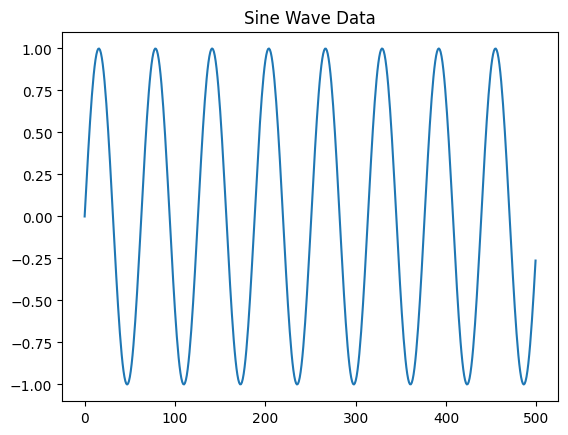

In [11]:
# [사인파(Sine Wave) 데이터 생성 함수]
# 예측할 대상이 되는 규칙적인 시계열 데이터를 생성합니다.
def generate_sine_wave(seq_length, num_samples):
    # np.linspace(start, stop, num): start부터 stop까지 num개의 점을 '동일한 간격'으로 생성합니다.
    #   - 이 x값들은 사인 함수의 입력 각도(radian) 역할을 합니다.
    x = np.linspace(0, seq_length, num_samples)
    # np.sin(x): x의 각 요소에 대해 사인 값을 계산하여 y값을 만듭니다.
    y = np.sin(x)
    return y

# [데이터 생성 및 시각화]
# seq_length=50: 사인파의 약 8주기(2*pi*8 ≈ 50)에 해당하는 데이터를 생성합니다.
# num_samples=500: 위 8주기를 500개의 세밀한 점으로 표현합니다.
data = generate_sine_wave(seq_length = 50, num_samples = 500)
plt.plot(data) # 생성된 데이터를 그래프로 그려서 확인합니다.
plt.title('Sine Wave Data')
plt.show()

In [12]:
# ====================================================================================================
# [이번 학습의 목표: 시계열 데이터를 위한 '슬라이딩 윈도우' 데이터 가공법 완벽 이해하기 (초심층 분석편)]
#
# [개념적 개요 및 왜 이 작업을 하는가?]
# RNN 모델은 "과거의 연속된 데이터를 보고, 바로 다음 미래를 예측"하는 방식으로 학습합니다.
# 하지만 우리가 가진 원본 데이터는 보통 `[10, 11, 12, 13, ...]` 처럼 하나의 긴 줄로 이어진 숫자 리스트입니다.
# RNN은 이 긴 데이터를 통째로 이해하지 못합니다. 대신, (과거 50일치 날씨 -> 51일차 날씨)와 같이
# 수많은 (문제, 정답) 쌍으로 이루어진 '문제집'이 필요합니다.
# `create_sequences` 함수의 목표는, 이 길고 연속적인 원본 데이터를 RNN이 학습할 수 있는 수백 개의
# (문제, 정답) 쌍으로 자동 변환해주는 '문제집 제작 기계'를 만드는 것입니다.
#
# [핵심 비유: 기상캐스터 훈련용 문제집 제작 🌦️]
#
# 1. 원본 데이터 (`data`): 지난 500일간의 '일일 온도 기록'이 담긴 긴 두루마리.
#
# 2. `seq_length`: "문제를 만들 때, 며칠 치의 과거 데이터를 보여줄 것인가?"를 정하는 기준. (예: 50일)
#
# 3. `create_sequences` 함수:
#    두루마리를 한 칸씩 옆으로 옮겨가며(Sliding) 다음과 같은 문제와 정답 쌍을 대량으로 만들어내는 '문제집 제작 기계'.
#    - 문제 1: "1일차~50일차 온도 기록을 보고, 51일차 온도를 예측하시오." / 정답 1: "51일차 실제 온도"
#    - 문제 2: "2일차~51일차 온도 기록을 보고, 52일차 온도를 예측하시오." / 정답 2: "52일차 실제 온도"
#    - ...
#
# [지금 무엇을 하고 있는가?]
# 우리는 지금부터 이 '문제집 제작 기계'가 어떻게 `for` 루프와 '슬라이싱'을 이용해
# 수많은 문제와 정답 쌍을 만들어내는지, 그리고 최종적으로 PyTorch RNN이 요구하는
# 특별한 3차원 텐서 형태로 어떻게 변환하는지를 배우고 있습니다.
# ====================================================================================================


# --- 1. 기본 도구 및 재료 준비 ---
# [흐름] 문제집 제작에 필요한 라이브러리와 가상의 '온도 기록' 데이터를 준비합니다.
import torch
import numpy as np

# [구동 과정] 실습을 위해 0부터 499까지의 숫자로 이루어진, 총 500일치의 가상 온도 기록을 생성합니다.
data = np.arange(500)


# --- 2. [핵심] '문제집 제작 기계' 함수 정의 ---
# [흐름] 긴 시계열 데이터를 (입력 시퀀스, 정답) 쌍으로 변환하는 함수를 설계합니다.
def create_sequences(data, seq_length):
    # [구동 과정] `sequences = []`, `labels = []`:
    #            앞으로 만들어질 '문제지'들과 '정답지'들을 담을 빈 노트를 각각 준비합니다.
    sequences = []
    labels = []

    # --- [가장 헷갈리는 부분: for 루프 심층 분석] ---
    # [개념] "모든 문제에는 반드시 '정답'이 존재해야 한다"는 간단한 원칙 하나만 기억하시면 됩니다.
    #        이 루프는 정답이 존재할 수 있는 마지막 문제까지만 정확하게 반복합니다.
    # [구동 과정 심층 분석] `for i in range(len(data) - seq_length):`
    # "두루마리를 한 칸씩 밀어가며 문제를 만든다."
    # 1. `len(data)`: 전체 온도 기록의 길이 (500일).
    # 2. `seq_length`: 문제 하나에 필요한 과거 기록의 길이 (50일).
    # 3. `len(data) - seq_length`: `500 - 50 = 450`. `range(450)`는 0부터 449까지의 숫자를 생성합니다.
    #    - 왜 이렇게 할까? 마지막으로 만들 수 있는 문제는 '449일차~498일차 기록'을 보고 '499일차'를 맞추는 문제입니다.
    #      이 문제는 `i=449`일 때 생성됩니다. (`data[449:499]` -> `data[499]`)
    #      만약 `i=450`까지 반복하면, `data[450:500]`을 문제로 만들 수는 있지만, 그에 대한 정답인 `data[500]`이
    #      원본 데이터에 존재하지 않으므로 에러가 발생합니다. 따라서 정답이 존재할 수 있는 마지막 지점까지만 반복하는 것입니다.
    for i in range(len(data) - seq_length):
        # --- [문제지 만들기] ---
        # [구동 과정] `sequences.append(data[i: i + seq_length])`
        # `data`에서 `i`번째 위치부터 `i + seq_length` 직전까지, 즉 `seq_length`(50)개 만큼의 데이터를 잘라냅니다.
        # (예: `i=0`일 때, `data[0:50]` -> 0~49번 데이터를 잘라 첫 번째 문제지로 만듦)
        # 잘라낸 문제지를 `sequences` 노트에 추가합니다.
        sequences.append(data[i: i + seq_length])

        # --- [정답지 만들기] ---
        # [구동 과정] `labels.append(data[i + seq_length])`
        # 문제지가 끝나는 지점(`i + seq_length`)의 '바로 다음' 데이터를 정답으로 지정합니다.
        # (예: `i=0`일 때, `data[50]` -> 50번 데이터를 첫 번째 정답지로 만듦)
        # 지정된 정답지를 `labels` 노트에 추가합니다.
        labels.append(data[i + seq_length])

    # --- [최종 손질 및 포장] ---
    # [흐름] 파이썬 리스트 형태로 만들어진 문제지와 정답지를, PyTorch가 요구하는 최종 '텐서' 형태로 변환합니다.

    # [구동 과정 심층 분석] `sequences = torch.tensor(...).unsqueeze(-1)`
    # 1. `np.array(sequences)`: 파이썬의 '리스트들의 리스트'를 하나의 NumPy 배열(2차원 행렬)로 변환합니다.
    #    -> 결과 모양: (450, 50) -> 450개의 문제지, 각 문제지는 50개의 숫자로 구성됨.
    # 2. `torch.tensor(...)`: 이 NumPy 배열을 PyTorch 텐서로 변환합니다.
    #    -> 결과 모양: (450, 50)
    # 3. `.unsqueeze(-1)`: [!!! 가장 중요 !!!]
    #    - 왜 필요한가?: RNN/LSTM과 같은 시계열 모델은 3차원 텐서 `[배치 크기, 시퀀스 길이, 입력 특성 수]`를 입력으로 기대합니다.
    #    - 현재 우리 텐서: `[450(문제 개수), 50(시퀀스 길이)]`. '입력 특성 수' 차원이 누락되었습니다.
    #    - 우리 데이터의 특성: 각 시간 단계(날짜)의 데이터는 '온도'라는 **1개**의 숫자(특성)로만 이루어져 있습니다.
    #    - `.unsqueeze(-1)`는 마지막(`-1`) 위치에 크기가 1인 차원을 **'추가'**하라는 명령입니다.
    #    - 최종 결과 모양: `(450, 50, 1)` -> 450개의 문제, 각 문제는 50개의 시간 단계, 각 시간 단계는 1개의 특성.
    #      이제 이 데이터는 RNN 모델의 입력 요구사항을 완벽하게 만족합니다.
    sequences = torch.tensor(np.array(sequences), dtype = torch.float32).unsqueeze(-1)

    # [구동 과정] `labels = torch.tensor(...)`: 정답지 리스트도 NumPy 배열을 거쳐 PyTorch 텐서로 변환합니다.
    #            정답은 각 시퀀스당 하나의 숫자이므로, 3차원으로 만들 필요가 없습니다.
    labels = torch.tensor(np.array(labels), dtype = torch.float32)

    return sequences, labels


# --- 3. '문제집 제작 기계' 실행 및 결과 확인 ---
# [구동 과정] `seq_length = 50`: "문제 하나당 과거 50일치의 데이터를 사용하겠다"고 설정합니다.
seq_length = 50
# [구동 과정] 위에서 정의한 `create_sequences` 함수를 호출하여, 최종적으로 완성된 문제지(`X`)와 정답지(`y`)를 받습니다.
X, y = create_sequences(data, seq_length=seq_length)
# [구동 과정] 완성된 문제지와 정답지의 모양을 출력하여 확인합니다.
print(f"입력(X) 모양: {X.shape}, 정답(y) 모양: {y.shape}")

입력(X) 모양: torch.Size([450, 50, 1]), 정답(y) 모양: torch.Size([450])


In [13]:
# ====================================================================================================
# [이번 학습의 목표: RNN + Linear 결합 모델의 구조와 데이터 흐름 완벽 이해하기]
#
# [개념적 개요 및 왜 이 작업을 하는가?]
# 이 코드의 목표는, 순차적인 데이터의 '문맥'을 파악하는 데 특화된 RNN과,
# 요약된 정보를 바탕으로 최종 결론을 내리는 데 뛰어난 Linear 레이어를 결합하여
# 정교한 시계열 예측 모델을 만드는 방법을 이해하는 것입니다.
# 이처럼 각기 다른 장점을 가진 레이어들을 '역할 분담'시켜 조립하는 것은
# 복잡한 딥러닝 모델을 설계하는 핵심적인 아이디어입니다.
#
# [모델의 두 가지 핵심 역할]
#
# 1. `self.rnn` (RNN 레이어): '문맥 요약기'
#    - 역할: 시간 순서대로 들어오는 여러 개의 데이터 조각들을 읽어서,
#            전체 순서에 담긴 의미나 패턴을 하나의 '요약 정보(벡터)'로 압축합니다.
#
# 2. `self.fc` (Linear 레이어): '최종 예측기'
#    - 역할: '문맥 요약기'가 만든 최종 '요약 정보' 하나만 입력받아서,
#            우리가 원하는 최종 예측값(하나의 숫자)을 출력합니다.
#
# [지금 무엇을 하고 있는가?]
# 우리는 지금부터 이 두 개의 역할을 가진 부품을 준비하고(`__init__`),
# 데이터가 들어왔을 때 이 부품들을 어떤 순서로 통과시킬지(`forward`)
# 그 전체 업무 프로세스를 구축하고 있습니다.
# ====================================================================================================


# --- 3. RNN 모델 설계 (두 가지 부품 조립) ---
class RNNModel(nn.Module):
    # [구동 과정] `__init__`: "모델에 필요한 부품들을 미리 정의하고 준비합니다."
    def __init__(self, input_size, hidden_size, num_layers):
        super().__init__()
        # --- [부품 1: '문맥 요약기' 준비] ---
        # [구동 과정] `self.rnn = nn.RNN(...)`:
        #            `nn.RNN` 클래스로 '문맥 요약기'를 생성하고 `self.rnn`에 할당합니다.
        # - `input_size`: "입력 데이터 한 조각(예: 하루치 날씨)이 몇 개의 숫자로 이루어졌나요?"
        # - `hidden_size`: "요약 정보를 몇 개의 숫자로 만들까요?"
        # - `num_layers`: "요약 작업을 몇 단계에 걸쳐서 할까요?"
        # - `batch_first=True`: "입력 데이터의 모양을 `(데이터 개수, 순서 길이, 특징 개수)` 순으로 하겠습니다."
        self.rnn = nn.RNN(input_size=input_size,
                          hidden_size=hidden_size,
                          num_layers=num_layers,
                          batch_first=True)

        # --- [부품 2: '최종 예측기' 준비] ---
        # [구동 과정] `self.fc = nn.Linear(...)`:
        #            `nn.Linear` 클래스로 '최종 예측기'를 생성하고 `self.fc`에 할당합니다.
        # - `hidden_size`: [!!! 가장 중요 !!!] "이 예측기는 `rnn`이 만든 '요약 정보'(`hidden_size`)와
        #                  똑같은 크기의 입력만 받을 수 있습니다."
        #                  RNN의 출력 크기와 Linear의 입력 크기는 반드시 일치해야 합니다.
        # - `1`: "이 예측기는 최종적으로 단 '하나'의 숫자(예: 다음 날의 예측값)를 출력합니다."
        self.fc = nn.Linear(hidden_size, 1)

    # --- [데이터 처리 절차 정의] ---
    # [구동 과정] `forward`: 데이터(`x`)가 들어왔을 때, 위에서 준비한 부품들을 어떤 순서로 통과시킬지 절차를 정의합니다.
    def forward(self, x):
        # [입력 `x`의 모양] `(데이터 개수, 순서 길이, 특징 개수)`, 예: `(450, 50, 1)`

        # --- [1단계: `rnn` 부품으로 전체 순서의 문맥을 요약합니다.] ---
        # [구동 과정 심층 분석] `out, _ = self.rnn(x)`
        # 1. `self.rnn(x)`: '문맥 요약기'(`self.rnn`)에 50일치 데이터 묶음(`x`)을 전달합니다.
        #    `rnn`은 첫날부터 50일차까지 데이터를 순서대로 읽으며, 각 날짜까지의 '중간 요약본'을 계속해서 만듭니다.
        # 2. `rnn`은 두 가지 결과물을 반환합니다.
        #    - 첫 번째 결과물: 50일 동안의 **모든 중간 요약본**을 모아놓은 `out`. (모양: `[450, 50, hidden_size]`)
        #    - 두 번째 결과물: **오직 마지막 50일차의 최종 요약본**만 담은 `_`.
        # 3. `out, _ = ...`: 우리는 더 다루기 쉬운 `out`을 사용하기로 하고, 두 번째 결과물은 언더스코어(`_`)를 사용해 무시합니다.
        out, _ = self.rnn(x)

        # --- [2단계: 모든 중간 요약본 중에서 '최종' 요약본만 추출합니다.] ---
        # [구동 과정 심층 분석] `ht = out[:,-1,:]`
        # "모든 중간 요약본이 담긴 `out`에서, 가장 마지막 요약본만 골라냅니다."
        # - `out` 텐서 (모양: `[450, 50, hidden_size]`) 에서,
        # - `:` (첫 번째 차원): 450개의 모든 데이터에 대해,
        # - `-1` (두 번째 차원): 50개의 순서 중 **가장 마지막 순서(-1)**의 요약본만,
        # - `:` (세 번째 차원): 그 요약본의 모든 내용(hidden_size 만큼의 숫자)을,
        # - 선택하여 `ht` 변수에 저장합니다. 이 `ht`가 바로 50일 전체를 요약한 최종 정보입니다. (모양: `[450, hidden_size]`)
        ht = out[:,-1,:]

        # --- [3단계: '최종' 요약본으로 '최종' 예측을 합니다.] ---
        # [구동 과정] `return self.fc(ht)`
        # '최종 예측기'(`self.fc`)에 방금 추출한 '최종 요약본'(`ht`)을 전달합니다.
        # `fc`는 이 요약본을 분석하여, 단 하나의 숫자(다음 날의 예측값)를 최종 결과로 반환합니다.
        return self.fc(ht)

In [14]:
# --- 4. 모델 학습 ---
# [모델 초기화]
input_size = 1 # 각 타임스텝의 특성 수
hidden_size = 20 # RNN의 기억 용량
num_layers = 2 # RNN 층의 수
model = RNNModel(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers)

In [20]:
# [손실 함수 및 옵티마이저]
loss_fn = nn.MSELoss() # 예측값과 실제값의 차이를 제곱하여 평균 내는, 회귀 문제의 표준 손실 함수
opt = torch.optim.Adam(model.parameters(), lr = 0.001)

In [16]:
# [학습 루프]
# (참고: 데이터가 작아서 DataLoader를 사용하지 않고, 전체 데이터를 한 번에 처리합니다.)
num_epochs = 100
for epoch in range(num_epochs):
    opt.zero_grad() # 그래디언트 초기화
    outputs = model(X) # 모델에 전체 입력 데이터(X)를 넣어 예측값을 얻습니다.
    # `outputs`의 모양은 [450, 1]이고, `y`의 모양은 [450,] 이므로,
    # `outputs.squeeze()`를 통해 불필요한 차원을 제거하여 모양을 [450,]으로 맞춰줍니다.
    loss = loss_fn(outputs.squeeze(), y)
    loss.backward() # 역전파
    opt.step() # 파라미터 업데이트

    if (epoch+1) % 10 == 0: # 10 에폭마다 손실을 출력
        print(f"Epoch : {epoch+1}/{num_epochs}, Loss : {loss.item():.4f}")

Epoch : 10/100, Loss : 0.1968
Epoch : 20/100, Loss : 0.0890
Epoch : 30/100, Loss : 0.0516
Epoch : 40/100, Loss : 0.0374
Epoch : 50/100, Loss : 0.0266
Epoch : 60/100, Loss : 0.0200
Epoch : 70/100, Loss : 0.0152
Epoch : 80/100, Loss : 0.0111
Epoch : 90/100, Loss : 0.0075
Epoch : 100/100, Loss : 0.0046


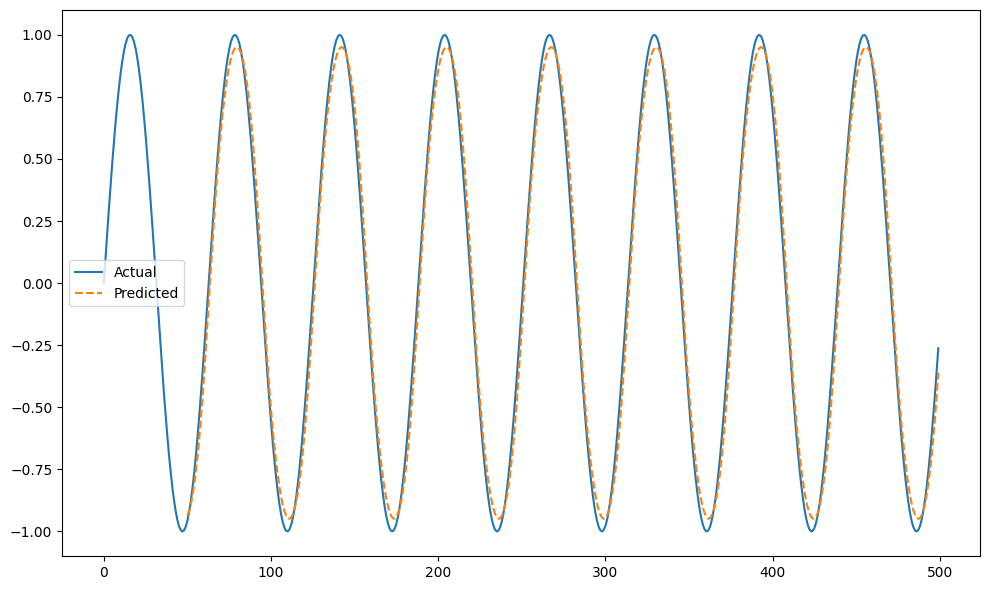

In [17]:
# --- 5. 예측 및 결과 시각화 ---
model.eval() # 모델을 평가 모드로 전환
with torch.no_grad(): # 그래디언트 계산 비활성화
    # 학습에 사용했던 동일한 입력 데이터(X)에 대한 모델의 예측값을 생성합니다.
    # `.numpy()`: 시각화를 위해 PyTorch 텐서를 NumPy 배열로 변환합니다.
    predictions = model(X).numpy()

# [결과 시각화]
plt.figure(figsize = (10, 6))
# 1. 실제 데이터(원본 사인파)를 파란색 실선으로 그립니다.
plt.plot(data, label = 'Actual')
# 2. 모델의 예측값을 주황색 점선으로 그립니다.
# [핵심] x축 위치 조정:
#    - 첫 번째 예측값(`predictions[0]`)은 0~49번 데이터를 보고 50번 데이터를 예측한 것입니다.
#      따라서 그래프 상에서 x좌표 50의 위치에 그려져야 합니다.
#    - `range(seq_length, seq_length + len(predictions))`: x좌표를 50부터 499까지 생성하여
#      예측값을 올바른 위치에 그려줍니다.
plt.plot(range(seq_length, seq_length + len(predictions)), predictions,
         label = 'Predicted',
         linestyle = 'dashed')

plt.legend()
plt.tight_layout() # 그래프 요소들이 겹치지 않게 레이아웃을 조정합니다.
plt.show()
# [시각화 결과 분석]
# - 주황색 점선(예측값)이 파란색 실선(실제값)의 패턴을 매우 유사하게 따라가는 것을 볼 수 있습니다.
# - 이는 RNN 모델이 사인파의 주기적인 패턴을 성공적으로 학습하여, 과거 데이터를 기반으로
#   미래 값을 정확하게 예측하고 있음을 의미합니다.